# 09 - Fundamental Group and Group-Ring Basics

When a topological space $X$ is not simply connected ($\pi_1(X) \neq 1$), the classical invariants like the intersection form must be upgraded. Instead of working over $\mathbb{Z}$, we work over the **group ring** $\mathbb{Z}[\pi_1(X)]$. This is the foundation of **Algebraic Surgery Theory**.

## Learning Goals
- **Extract Fundamental Groups**: Compute $\pi_1(X)$ presentations from CW complexes and visualize their generators.
- **Simplify Presentations**: Use Tietze-like moves to reduce generators and relations.
- **Understand Group Rings**: Perform addition and multiplication in $\mathbb{Z}[G]$.
- **Involution and Duality**: Learn about the anti-involution $w: \mathbb{Z}[G] \to \mathbb{Z}[G]$ that defines topological duality.
- **Visualizing Cayley Traces**: Trace generators through the complex to visualize non-trivial loops.

## Formal Grounding

### Fundamental Group Presentations
A group $G$ is often represented by generators $S$ and relators $R$:
$$G = \langle g_1, \dots, g_n \mid r_1, \dots, r_m \rangle$$

### The Group Ring $\mathbb{Z}[G]$
The group ring consists of formal sums:
$$x = \sum_{g \in G} a_g g, \quad a_g \in \mathbb{Z}$$
Multiplication is defined by the group law: $(\sum a_g g)(\sum b_h h) = \sum_{g,h} (a_g b_h) (gh)$.

### Involution (Anti-automorphism)
In surgery theory, we use an involution $\bar{x}$ defined by:
$$\overline{\sum a_g g} = \sum a_g \omega(g) g^{-1}$$
where $\omega(g) \in \{1, -1\}$ is the orientation character.

| Concept | Algebraic Object | Topological Meaning |
|---|---|---|
| **$\pi_1(X)$** | Group Presentation | Loops in the space modulo homotopy |
| **$\mathbb{Z}[\pi_1]$** | Ring Structure | "Local" coefficients for surgery |
| **Relator** | $r_i = 1$ | A 2-cell boundary killing a loop |
| **Orientation** | $w: G \to \{ \pm 1 \}$ | Whether a loop reverses orientation |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pysurgery as ps
from pysurgery.core.fundamental_group import FundamentalGroup, extract_pi_1_with_traces, infer_standard_group_descriptor
from pysurgery.core.group_rings import GroupRingElement

# Performance Check: Julia Acceleration
from pysurgery.bridge.julia_bridge import julia_engine
if julia_engine.available:
    julia_engine.warmup()

print('=' * 70)
print('09 - Fundamental Group and Group Rings: Setup Complete')
print('=' * 70)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
09 - Fundamental Group and Group Rings: Setup Complete


## Part 1: Presentations, Simplification, and Traces

We extract presentations from CW complexes and use automated simplification to reach a minimal set of generators. We can also trace these generators geometrically onto the underlying space.


### Example 9.1: The Torus $\pi_1(T^2)$ Generators

In [2]:
# A small figure-eight-like double loop complex to demonstrate generators visually
# We build two disjoint triangle loops joined at a central vertex
pts = np.array([
    [-2.0, 0.0, 0.0],
    [-1.0, 1.0, 0.0],
    [-1.0, -1.0, 0.0],
    [0.0, 0.0, 0.0], # Central joining vertex
    [1.0, 1.0, 0.0],
    [1.0, -1.0, 0.0],
    [2.0, 0.0, 0.0],
], dtype=float)

simplices = [
    (0, 1), (1, 3), (3, 2), (2, 0), # Left loop
    (3, 4), (4, 6), (6, 5), (5, 3)  # Right loop
]

# We must use GUDHI or directly build a CWComplex to extract pi_1 traces
try:
    import gudhi
    st = gudhi.SimplexTree()
    for v in range(len(pts)):
        st.insert([v])
    for s in simplices:
        st.insert(list(s))
    
    from pysurgery.integrations.gudhi_bridge import extract_complex_data
    boundaries, bridge_cells, _, _ = extract_complex_data(st)
    cw = ps.CWComplex(cells=bridge_cells, attaching_maps=boundaries, coefficient_ring="Z")
    
    # Extract pi_1 with geometric traces
    pi1_with_traces = extract_pi_1_with_traces(cw, simplify=True, generator_mode="optimized")
    
    print(f"Extracted pi_1 generators: {list(pi1_with_traces.generators)}")
    print(f"Relations: {list(pi1_with_traces.relations)}")
    
    # Plot using Plotly
    fig = go.Figure()
    
    # Plot vertices
    fig.add_trace(go.Scatter3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
        mode="markers+text", text=[str(i) for i in range(len(pts))],
        textposition="top center", marker=dict(size=5, color="royalblue"),
        name="Vertices"
    ))
    
    # Plot edges (background)
    xs, ys, zs = [], [], []
    for u, v in simplices:
        xs.extend([pts[u, 0], pts[v, 0], None])
        ys.extend([pts[u, 1], pts[v, 1], None])
        zs.extend([pts[u, 2], pts[v, 2], None])
    fig.add_trace(go.Scatter3d(
        x=xs, y=ys, z=zs, mode="lines",
        line=dict(width=2, color="lightgray"), name="1-skeleton"
    ))
    
    # Plot generator traces
    colors = ["red", "purple"]
    for i, tr in enumerate(pi1_with_traces.traces):
        path = tr.undirected_edge_path
        tx, ty, tz = [], [], []
        for u, v in path:
            tx.extend([pts[int(u), 0], pts[int(v), 0], None])
            ty.extend([pts[int(u), 1], pts[int(v), 1], None])
            tz.extend([pts[int(u), 2], pts[int(v), 2], None])
        fig.add_trace(go.Scatter3d(
            x=tx, y=ty, z=tz, mode="lines",
            line=dict(width=6, color=colors[i % len(colors)]),
            name=f"pi_1 Generator {tr.generator}"
        ))
        
    fig.update_layout(title="Figure Eight pi_1 Generators", height=600)
    fig.show()

except ImportError:
    print("GUDHI is required for this visualization example.")

Extracted pi_1 generators: ['g_3', 'g_7']
Relations: []


### Example 9.2: $RP^2$ and Non-trivial Torsion

In [3]:
# RP2 has one generator a and relator a^2 = 1
pi1_rp2 = FundamentalGroup(
    generators=['a'],
    relations=[['a', 'a']]
)

print(f'RP2 Presentation: {pi1_rp2}')
descriptor = infer_standard_group_descriptor(pi1_rp2)
print(f'Inferred Standard Group: {descriptor}')

RP2 Presentation: < a | aa >
Inferred Standard Group: Z_2


## Part 2: Group Ring Algebra ($\mathbb{Z}[G]$)

Group ring elements are sparse mappings from group elements (words) to integer coefficients.


### Example 9.3: Multiplication in $\mathbb{Z}[\mathbb{Z}]$

In [4]:
# Define the group law for Z (infinite cyclic)
def z_law(g1, g2):
    return str(int(g1) + int(g2))

def z_inv(g):
    return str(-int(g))

# x = 1*g1 + 2*g2
x = GroupRingElement({'1': 1, '2': 2}, group_law=z_law, inverse_law=z_inv)
# y = 3*g0 (identity)
y = GroupRingElement({'0': 3}, group_law=z_law, inverse_law=z_inv)

print(f'x = {x.coeffs}')
print(f'y = {y.coeffs}')

z = x * y
print(f'x * y = {z.coeffs}')

w = x * x
print(f'x * x = {w.coeffs}')

x = {'1': 1, '2': 2}
y = {'0': 3}
x * y = {'1': 3, '2': 6}
x * x = {'2': 1, '3': 4, '4': 4}


### Example 9.4: Involution (Duality)

In [5]:
# The involution maps g -> g^-1 (assuming w=1)
x_bar = x.involution()
print(f'x     = {x.coeffs}')
print(f'x_bar = {x_bar.coeffs}')

# Check x * x_bar (should be symmetric)
prod = x * x_bar
print(f'x * x_bar = {prod.coeffs}')

x     = {'1': 1, '2': 2}
x_bar = {'1': 1, '-2': 2}
x * x_bar = {'2': 1, '-1': 2, '3': 2, '0': 4}


## Part 3: Visualizing Group Ring Distributions

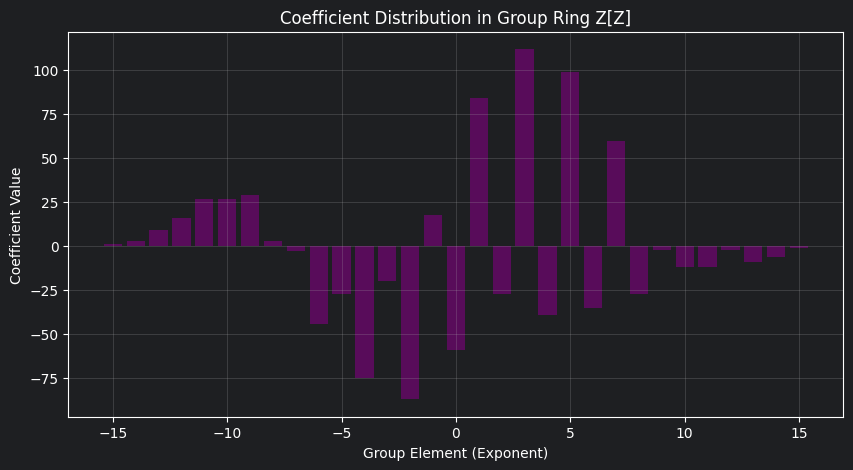

In [6]:
# Visualizing a "Random Walk" or heat map of coefficients in Z[Z]
# for a product of many small elements.
size = 20
coeffs = {str(i): np.random.randint(-2, 3) for i in range(-5, 6)}
x_rand = GroupRingElement(coeffs, group_law=z_law, inverse_law=z_inv)

# Multiply repeatedly
y_res = x_rand
for _ in range(2):
    y_res = y_res * x_rand

# Extract data for plotting
indices = [int(k) for k in y_res.coeffs.keys()]
values = list(y_res.coeffs.values())

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(indices, values, color='purple', alpha=0.6)
ax.set_title('Coefficient Distribution in Group Ring Z[Z]')
ax.set_xlabel('Group Element (Exponent)')
ax.set_ylabel('Coefficient Value')
ax.grid(True, alpha=0.3)
plt.show()

## Failure Modes

1. **Non-Terminating Simplification**: Presentation simplification is an undecidable problem in general. Large presentations might hang or reach a sub-optimal local minimum.
2. **Infinite Multiplication**: Since group rings are sparse, multiplying elements in infinite groups can lead to an explosion in the number of terms if not managed.
3. **Invalid Word Normalization**: Using inconsistent generator labels (e.g., mixing 'a' and 'g1') will lead to incorrect group ring products.


In [7]:
try:
    # Error: Mixed laws or missing laws
    bad_x = GroupRingElement({'a': 1})
    bad_y = GroupRingElement({'b': 1})
    bad_x * bad_y
except Exception as e:
    print(f'Caught expected error: {e}')

Caught expected error: Group order must be specified for exact ring multiplication, unless group_law is provided.


## Summary Checklist
- [x] Extracted $\pi_1(X)$ presentations for standard surfaces and visualized their traces.
- [x] Simplified group presentations using automated moves.
- [x] Performed addition and multiplication in $\mathbb{Z}[G]$.
- [x] Applied the surgery involution $x \mapsto \bar{x}$.
- [x] Visualized coefficient distributions in the group ring.

## Exercises
1. **The Sphere Trace**: Create a point cloud for a sphere $S^2$, extract $\pi_1$, and show that its generator set is empty.
2. **Free Group Multiplication**: Define a group law for the free group $F_2 = \langle a, b \rangle$ and multiply $(1+a)$ by $(1-a)$.
3. **Orientation Character**: Create an involution that uses $\omega(g) = -1$ for a specific generator and observe its effect.
4. **Group Invariants**: Use `infer_standard_group_descriptor` to identify the group $\langle a, b \mid a^2, b^2 \rangle$.
5. **Matrix Representation**: Represent a group ring element of a finite group as a matrix.

## Key Takeaways
- **Fundamental Groups** are the algebraic "soul" of non-simply connected spaces.
- Tracing generators geometrically helps bridge the gap between combinatorial and continuous topology.
- **Group Rings** allow us to do linear algebra "with memory" of the group structure.
- **Involution** is the algebraic tool for handling orientation and duality.

**Ready for [10 - K-Theory and Bass-Heller-Swan Workflows](./10_k_theory_and_bass_heller_swan_workflows.ipynb)**


### Quick Mapper Application

Recently introduced, the `quick_mapper` method for simplex trees preserves topology while reducing complexity. Here we build a Torus, apply `quick_mapper`, use `expand` to increase its simplex tree to 2 dimensions, compute the homology generators of all degrees and the fundamental group, and plot its vertices, edges, and generators using plotly.

In [ ]:
import numpy as np
import plotly.graph_objects as go
import pysurgery as ps
import gudhi

from pysurgery.core.homology_generators import (
    compute_homology_basis_from_simplex_tree,
    compute_optimal_h1_basis_from_simplex_tree
)
from pysurgery.core.fundamental_group import extract_pi_1_with_traces
from pysurgery.integrations.gudhi_bridge import extract_complex_data

# Build a Torus point cloud and complex
R, r = 3.0, 1.0
nu, nv = 6, 6  # slightly denser to show simplification
pts_qm = []
simplices_qm = []

def idx(i, j): return i * nv + j

for i in range(nu):
    u = 2.0 * np.pi * i / nu
    for j in range(nv):
        v = 2.0 * np.pi * j / nv
        pts_qm.append([(R + r * np.cos(v)) * np.cos(u), (R + r * np.cos(v)) * np.sin(u), r * np.sin(v)])

for i in range(nu):
    ip = (i + 1) % nu
    for j in range(nv):
        jp = (j + 1) % nv
        a, b, c, d = idx(i, j), idx(ip, j), idx(ip, jp), idx(i, jp)
        simplices_qm.extend([(a, b, c), (a, c, d)])

pts_qm = np.array(pts_qm)

# 1. Create Simplicial Complex and apply quick_mapper
sc_torus = ps.SimplicialComplex.from_maximal_simplices(simplices_qm)
# 2. Apply quick_mapper and expand to 2 dimensions
sc_qm = sc_torus.quick_mapper(preserve_topology=True, max_loops=3).expand(2)

# 3. Convert back to GUDHI SimplexTree
st_qm = gudhi.SimplexTree()
for d in sc_qm.dimensions:
    for s in sc_qm.n_simplices(d):
        st_qm.insert(list(s))

# 4. Compute Homology Generators
h0_qm = compute_homology_basis_from_simplex_tree(st_qm, dimension=0)
h1_qm = compute_optimal_h1_basis_from_simplex_tree(st_qm, point_cloud=pts_qm, max_cycles=8)
h2_qm = compute_homology_basis_from_simplex_tree(st_qm, dimension=2, mode="valid")

print(f"Quick Mapper H0 Generators: {h0_qm.rank}")
print(f"Quick Mapper H1 Generators: {h1_qm.rank}")
print(f"Quick Mapper H2 Generators: {h2_qm.rank}")

# 5. Compute Fundamental Group Generators
boundaries, bridge_cells, _, _ = extract_complex_data(st_qm)
cw = ps.CWComplex(cells=bridge_cells, attaching_maps=boundaries, coefficient_ring="Z")
pi1_with_traces = extract_pi_1_with_traces(cw, simplify=True, generator_mode="optimized")

print(f"Extracted pi_1 generators: {list(pi1_with_traces.generators)}")
print(f"Relations: {list(pi1_with_traces.relations)}")

# 6. Plotting
fig_qm = go.Figure()

# Plot Quick Mapper Vertices and Edges
qm_vertices = list(sc_qm.n_simplices(0))
qm_v_coords = np.array([pts_qm[v[0]] for v in qm_vertices])

fig_qm.add_trace(go.Scatter3d(
    x=qm_v_coords[:, 0], y=qm_v_coords[:, 1], z=qm_v_coords[:, 2],
    mode="markers", marker=dict(size=8, color="black"),
    name="Quick Mapper Vertices"
))

qm_edges = list(sc_qm.n_simplices(1))
xs, ys, zs = [], [], []
for u, v in qm_edges:
    xs.extend([pts_qm[u, 0], pts_qm[v, 0], None])
    ys.extend([pts_qm[u, 1], pts_qm[v, 1], None])
    zs.extend([pts_qm[u, 2], pts_qm[v, 2], None])

fig_qm.add_trace(go.Scatter3d(
    x=xs, y=ys, z=zs, mode="lines",
    line=dict(width=3, color="lightgray"), name="Quick Mapper Edges"
))

# Plot H1 cycles
colors_h1 = ["red", "purple", "green", "orange"]
for gi, gen in enumerate(h1_qm.generators[:2]):
    edges = [tuple(sorted(e)) for e in gen.support_edges]
    hx, hy, hz = [], [], []
    for u, v in edges:
        hx.extend([pts_qm[u,0], pts_qm[v,0], None])
        hy.extend([pts_qm[u,1], pts_qm[v,1], None])
        hz.extend([pts_qm[u,2], pts_qm[v,2], None])
    fig_qm.add_trace(go.Scatter3d(
        x=hx, y=hy, z=hz, mode="lines",
        line=dict(width=7, color=colors_h1[gi % len(colors_h1)]),
        name=f"H1 Generator {gi}"
    ))

# Plot pi_1 traces
for i, tr in enumerate(pi1_with_traces.traces):
    path = tr.undirected_edge_path
    tx, ty, tz = [], [], []
    for u, v in path:
        tx.extend([pts_qm[int(u), 0], pts_qm[int(v), 0], None])
        ty.extend([pts_qm[int(u), 1], pts_qm[int(v), 1], None])
        tz.extend([pts_qm[int(u), 2], pts_qm[int(v), 2], None])
    fig_qm.add_trace(go.Scatter3d(
        x=tx, y=ty, z=tz, mode="lines",
        line=dict(width=5, dash='dash', color=colors_h1[(i+2) % len(colors_h1)]),
        name=f"pi_1 Generator {tr.generator}"
    ))

# Plot H2 faces (semi-transparent)
h2_faces_qm = []
for gen in h2_qm.generators:
    for simplex in gen.support_simplices:
        if len(simplex) == 3:
            h2_faces_qm.append(tuple(sorted(simplex)))
h2_faces_qm = list(set(h2_faces_qm))

if h2_faces_qm:
    fig_qm.add_trace(go.Mesh3d(
        x=pts_qm[:, 0], y=pts_qm[:, 1], z=pts_qm[:, 2],
        i=[f[0] for f in h2_faces_qm], j=[f[1] for f in h2_faces_qm], k=[f[2] for f in h2_faces_qm],
        opacity=0.5, color="gold", name="H2 generator support"
    ))

fig_qm.update_layout(title="Quick Mapper Homology and Fundamental Group on Torus", height=700)
fig_qm.show()